In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("D:/SALEM/Machine Learning Models/4-Response Time Prediction (ETA Model)/Dataset/response_time_dataset.csv")

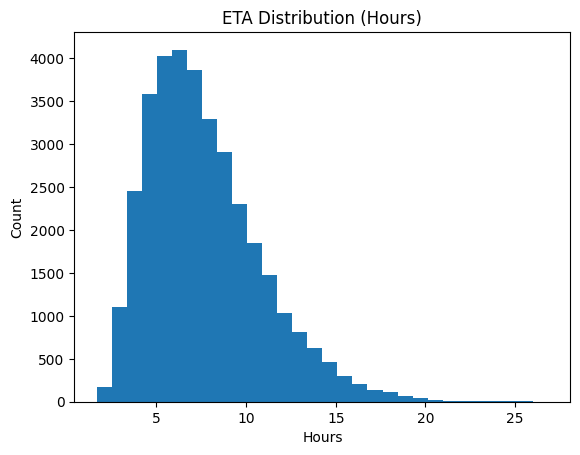

In [3]:
plt.hist(df["estimated_resolution_time"], bins=30)
plt.title("ETA Distribution (Hours)")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.show()

In [4]:
features = [
    "severity_score",
    "area_load",
    "team_efficiency",
    "hour",
    "day_of_week"
]

X = df[features]
y = df["estimated_resolution_time"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)


RMSE: 1.7955711513615369


In [ ]:
joblib.dump(model, "D:/SALEM/Machine Learning Models/4-Response Time Prediction (ETA Model)/modelpk/eta_model.pkl")



In [ ]:
df["predicted_eta"] = model.predict(X)
df.to_csv("D:/SALEM/Machine Learning Models/4-Response Time Prediction (ETA Model)/Dataset/eta_predictions.csv", index=False)